In [1]:
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from mpmath import pcfd
from tqdm import tqdm
import sys
sys.path.append("../../../src/")
import kblock_ising_model as kb
import kibble_zurek as kz
from time import time


In [140]:

#P_n correlations do not calculate connected correlator at all
def P_n_correlations(n,l,state, even = True):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = kb.all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = kz.Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(kz.sigma_general(indices,state))*degen)
        else:
            dat.append(kz.sigma_general(indices,state)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:147: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


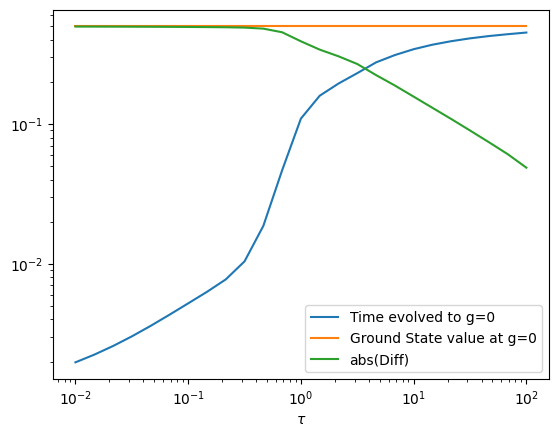

In [4]:
#Simple Test
L = 100
n = 10
taus = np.logspace(-2,2,25)
Kibble_Zurek = []
Ground_State = []
Delta_values = []

for tau in taus:
    t= tau
    state_t = kz.state(L,tau,t)
    k0 = kb.k_vals(L)
    #U0 needs -g because of different conventions
    U0 = kb.U(k0,-kz.g(t,tau))

    P_kz = kz.P_n(n,state_t)
    P0 = kb.P_n(n,U0,k0)
    diff = kz.delta(state_t,[U0,k0],n)

    Kibble_Zurek+= [P_kz]
    Ground_State += [P0]
    Delta_values += [diff]
plot(taus,Kibble_Zurek,label="Time evolved to g=0")
plot(taus,Ground_State,label="Ground State value at g=0")
plot(taus,Delta_values,label="abs(Diff)")
plt.xlabel(r"$\tau$")
plt.legend()
plt.yscale("log")
plt.xscale("log")

In [24]:
#Simple Test
L = 200
n = 1
ns = np.arange(1,11)
taus = np.logspace(-2,2,50)
Data_array = np.zeros([len(ns),len(taus)])

Delta_values = []

for tau_i, tau in enumerate(taus):
    t = np.linspace(-3*tau,tau,100)
    delta_t = np.zeros([len(ns),len(t)])
    for t_i,ti in (enumerate(tqdm(t))):
        state_t = kz.state(L,tau,ti)
        k0 = kb.k_vals(L)
        #U0 needs -g because of different conventions
        U0 = kb.U(k0,-kz.g(ti,tau))

        P_kz = kz.P_n(n,state_t)
        P0 = kb.P_n(n,U0,k0)
        for n_i,n in enumerate(ns):
            diff = kz.delta(state_t,[U0,k0],n)

            delta_t[n_i,t_i]= diff

    delta_t=delta_t.mean(axis=1)
    for n_i in range(len(ns)):
        Data_array[n_i,tau_i] = delta_t[n_i]

100%|██████████| 100/100 [01:05<00:00,  1.53it/s]


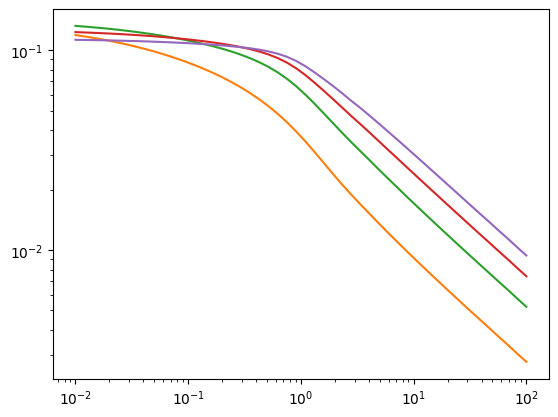

In [26]:
plt.loglog(taus,Data_array[::2].T)


In [ ]:
file_name= f"time_insensitive_prob_density_difference_nmax={ns[-1]}_mintau=-E2_maxtau=E2.npy"

folder = "Data/"

path = folder+file_name
print(path)
#np.save(path,Data_array)

Data/time_insensitive_prob_density_difference_nmax=10_mintau=-E2_maxtau=E2.npy


In [74]:
X= np.load(path)[1:]
labels = np.arange(2,len(X)+2)

(0.1, 100.0)

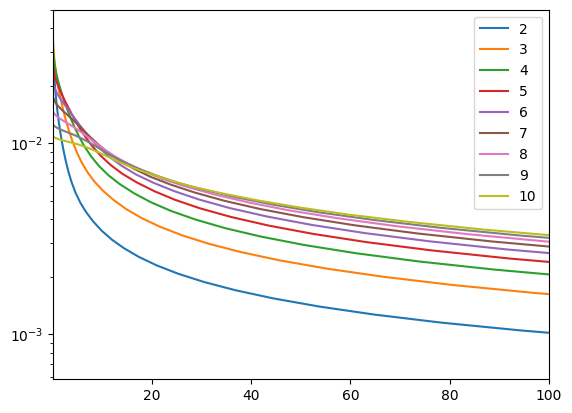

In [94]:
for i in range(len(labels)):
    l = labels[i]
    dat = X[i]
    plot(taus*l,dat/l,label=labels[i])
#plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlim(10e-2,100)

array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])

In [169]:
#Simple Test
L = 100
n = 1
#data_groundstate = np.zeros([len(taus_2dplots,len(t))])
N_t = 100

r = np.arange(1,20)
taus_2dplots= np.logspace(-2,2,5)
t_range = np.linspace(-3,3,N_t)
data = np.zeros([len(taus_2dplots),N_t,len(r)])

for tau_i, tau0 in enumerate(taus_2dplots):
    t = tau0*t_range

    for t_i,t0 in (enumerate(tqdm(t))):
        state_t = kz.state(L,tau0,t0)
        P = kz.P_n(n,state_t)
        for r_i, r0 in enumerate(r):
            PP = P_n_correlations(n,r0,state_t)
            x = PP
            data[tau_i,t_i,r_i] = x

folder_path = "Data/"
file_path = folder_path+f"n={n}_PP_correlator.npz"

np.savez(
    file_path,
    data=data,
    taus=taus_2dplots,
    t_range=t_range,
    r=r
)

100%|██████████| 100/100 [00:05<00:00, 18.32it/s]


In [167]:
#Simple Test
L = 100
n = 2
#data_groundstate = np.zeros([len(taus_2dplots,len(t))])
N_t = 100

r = np.arange(1,20)
taus_2dplots= np.logspace(-2,2,5)
t_range = np.linspace(-3,3,N_t)
data = np.zeros([len(taus_2dplots),N_t,len(r)])

for tau_i, tau0 in enumerate(taus_2dplots):
    t = tau0*t_range

    for t_i,t0 in (enumerate(tqdm(t))):
        state_t = kz.state(L,tau0,t0)
        P = kz.P_n(n,state_t)
        for r_i, r0 in enumerate(r):
            PP = P_n_correlations(n,r0,state_t)
            x = PP
            data[tau_i,t_i,r_i] = x

folder_path = "Data/"
file_path = folder_path+f"n={n}_PP_correlator.npz"

np.savez(
    file_path,
    data=data,
    taus=taus_2dplots,
    t_range=t_range,
    r=r
)

100%|██████████| 100/100 [00:10<00:00,  9.67it/s]


In [168]:
#Simple Test
L = 100
n = 4
#data_groundstate = np.zeros([len(taus_2dplots,len(t))])
N_t = 100

r = np.arange(1,20)
taus_2dplots= np.logspace(-2,2,5)
t_range = np.linspace(-3,3,N_t)
data = np.zeros([len(taus_2dplots),N_t,len(r)])

for tau_i, tau0 in enumerate(taus_2dplots):
    t = tau0*t_range

    for t_i,t0 in (enumerate(tqdm(t))):
        state_t = kz.state(L,tau0,t0)
        P = kz.P_n(n,state_t)
        for r_i, r0 in enumerate(r):
            PP = P_n_correlations(n,r0,state_t)
            x = PP
            data[tau_i,t_i,r_i] = x

folder_path = "Data/"
file_path = folder_path+f"n={n}_PP_correlator.npz"

np.savez(
    file_path,
    data=data,
    taus=taus_2dplots,
    t_range=t_range,
    r=r
)

100%|██████████| 100/100 [02:25<00:00,  1.46s/it]


In [170]:
#Simple Test
L = 100
n = 6
#data_groundstate = np.zeros([len(taus_2dplots,len(t))])
N_t = 100

r = np.arange(1,20)
taus_2dplots= np.logspace(-2,2,5)
t_range = np.linspace(-3,3,N_t)
data = np.zeros([len(taus_2dplots),N_t,len(r)])

for tau_i, tau0 in enumerate(taus_2dplots):
    t = tau0*t_range

    for t_i,t0 in (enumerate(tqdm(t))):
        state_t = kz.state(L,tau0,t0)
        P = kz.P_n(n,state_t)
        for r_i, r0 in enumerate(r):
            PP = P_n_correlations(n,r0,state_t)
            x = PP
            data[tau_i,t_i,r_i] = x

folder_path = "Data/"
file_path = folder_path+f"n={n}_PP_correlator.npz"

np.savez(
    file_path,
    data=data,
    taus=taus_2dplots,
    t_range=t_range,
    r=r
)

100%|██████████| 100/100 [1:00:07<00:00, 36.07s/it]


In [162]:
np.load("Data/n=1_PP_correlator.npz")["data"]

array([[[0.26826992, 0.25120473, 0.25002333, 0.24999079, 0.24999805,
         0.24999975, 0.24999998, 0.25      , 0.25      ],
        [0.26917016, 0.25120377, 0.2499974 , 0.24998461, 0.24999712,
         0.24999965, 0.24999997, 0.25      , 0.25      ],
        [0.27003494, 0.25115689, 0.24995755, 0.24997591, 0.24999591,
         0.24999954, 0.24999997, 0.25      , 0.25      ],
        [0.27082382, 0.25104444, 0.24989905, 0.24996409, 0.24999441,
         0.24999944, 0.24999997, 0.25      , 0.25      ],
        [0.27148331, 0.25084157, 0.24981647, 0.24994872, 0.24999274,
         0.2499994 , 0.25      , 0.25000001, 0.25      ],
        [0.27194443, 0.25051794, 0.24970425, 0.24992983, 0.2499912 ,
         0.24999952, 0.25000007, 0.25000002, 0.25      ],
        [0.27212055, 0.2500384 , 0.24955781, 0.24990844, 0.24999043,
         0.24999995, 0.25000019, 0.25000004, 0.25      ],
        [0.27190585, 0.24936496, 0.24937558, 0.24988735, 0.24999148,
         0.25000087, 0.25000038, 0.2500000